# Phase 2 - Clustering and Labeling

Discover wine profiles with K-Means, justify the choice of k (elbow + silhouette +
Davies-Bouldin), visualize the clusters in 2D with PCA, interpret the centroids and
name the clusters. Figures are saved to `reports/figures/`.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
os.chdir(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from preprocessing import FEATURE_COLUMNS
from clustering import (evaluate_k_range, fit_kmeans, compare_algorithms,
                        describe_clusters, assign_labels, project_2d)

sns.set_theme(style='whitegrid')
os.makedirs('reports/figures', exist_ok=True)

df = pd.read_csv('data/processed/wine_combined.csv')
# Scale the 11 features before clustering (distances must be comparable).
scaler = StandardScaler()
X = scaler.fit_transform(df[FEATURE_COLUMNS])
print('Clustering on', X.shape)

Clustering on (5320, 11)


## 1. Choosing k - elbow, silhouette and Davies-Bouldin

In [2]:
scores = evaluate_k_range(X, k_min=2, k_max=10)
scores

,k,inertia,silhouette,davies_bouldin
0,2,46016.986326,0.270452,1.620530
1,3,37766.967923,0.230574,1.503056
2,4,33679.238982,0.243424,1.485640
3,5,31395.517236,0.178213,1.766119
4,6,29431.559826,0.184597,1.579566
5,7,27952.142448,0.177235,1.577385
6,8,27022.853941,0.159601,1.683811
7,9,26040.886130,0.141228,1.748336
8,10,25156.359623,0.144311,1.706623


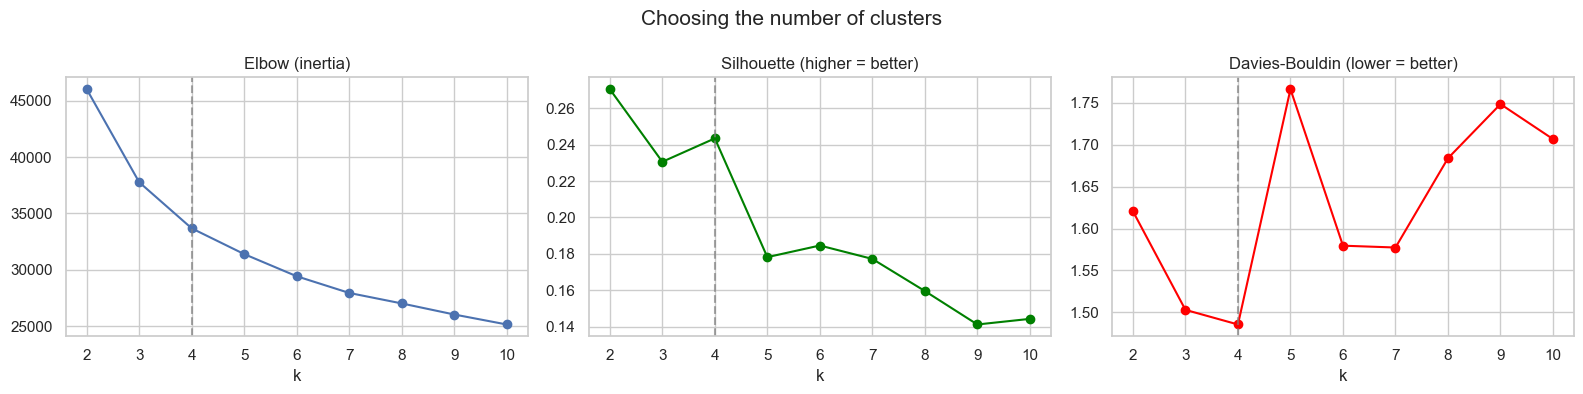

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(scores['k'], scores['inertia'], 'o-')
axes[0].set_title('Elbow (inertia)'); axes[0].set_xlabel('k')
axes[1].plot(scores['k'], scores['silhouette'], 'o-', color='green')
axes[1].set_title('Silhouette (higher = better)'); axes[1].set_xlabel('k')
axes[2].plot(scores['k'], scores['davies_bouldin'], 'o-', color='red')
axes[2].set_title('Davies-Bouldin (lower = better)'); axes[2].set_xlabel('k')
# Mark the chosen k.
for ax in axes:
    ax.axvline(4, color='gray', linestyle='--', alpha=0.7)
plt.suptitle('Choosing the number of clusters', fontsize=15)
plt.tight_layout()
plt.savefig('reports/figures/clustering_k_selection.png', dpi=120)
plt.show()

## 2. Fit K-Means with k=4

k=4 gives the best Davies-Bouldin score, a silhouette close to the maximum, and 4
interpretable profiles (k=2 would just separate red vs white).

In [4]:
chosen_k = 4
_, labels = fit_kmeans(X, n_clusters=chosen_k)
print('Cluster sizes:', np.bincount(labels))

Cluster sizes: [1409  852  590 2469]


## 3. Compare K-Means with Agglomerative and DBSCAN

In [5]:
comparison = compare_algorithms(X, n_clusters=chosen_k)
comparison

,algorithm,n_clusters,silhouette
0,KMeans,4,0.243424
1,Agglomerative,4,0.218363
2,DBSCAN,3,0.108263


## 4. Visualize the clusters in 2D (PCA)

Clustering happens in 11D; PCA projects to 2D so we can see the groups.

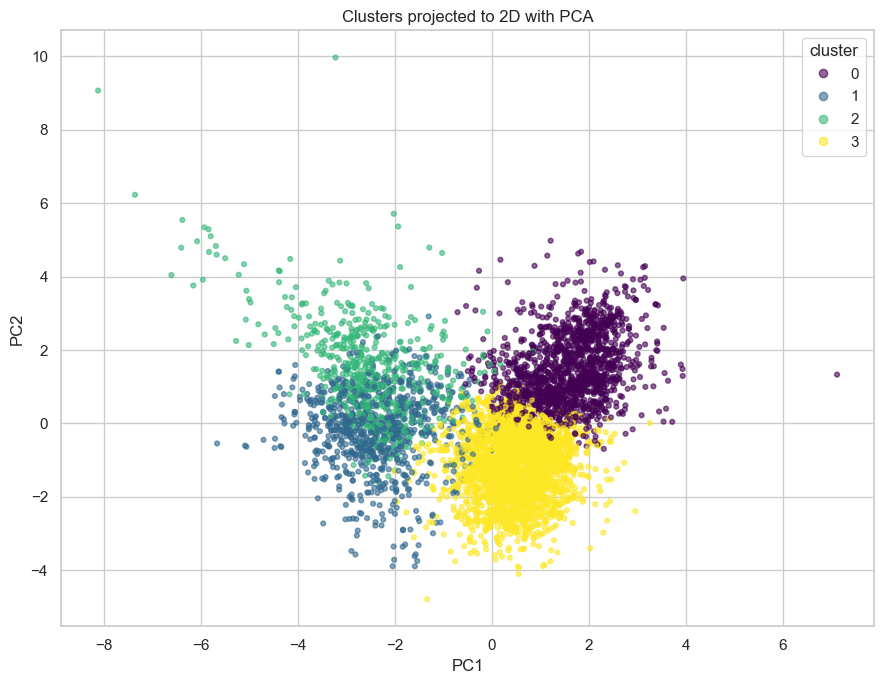

In [6]:
coords = project_2d(X)
plt.figure(figsize=(9, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='viridis',
                      s=12, alpha=0.6)
plt.legend(*scatter.legend_elements(), title='cluster')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Clusters projected to 2D with PCA')
plt.tight_layout()
plt.savefig('reports/figures/clustering_pca_2d.png', dpi=120)
plt.show()

## 5. Interpret the clusters (centroid profiles)

In [7]:
profiles = describe_clusters(df, labels)
profiles

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
cluster,,,,,,,,,,,
0,6.940064,0.285621,0.359375,10.638396,0.052966,46.202271,170.518098,0.996733,3.167104,0.493251,9.622380
1,7.245540,0.612365,0.136268,2.477054,0.078180,16.608568,53.144953,0.996006,3.372535,0.587711,10.233666
2,9.687797,0.417585,0.460373,2.773729,0.101393,15.140678,48.918644,0.997493,3.200729,0.735644,10.526158
3,6.770838,0.267404,0.324143,3.237141,0.040717,29.004658,118.089915,0.992067,3.212203,0.489149,11.192593


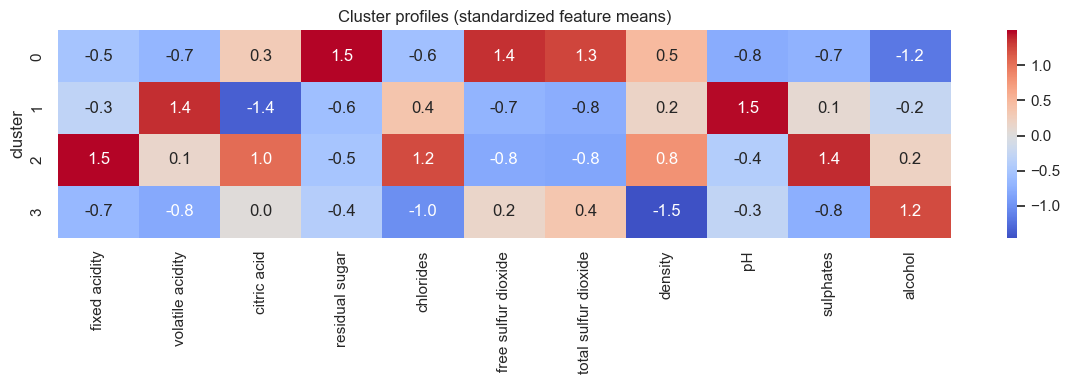

In [8]:
# Heatmap of standardized profiles: makes it easy to see what defines each cluster.
profiles_z = (profiles - profiles.mean()) / profiles.std()
plt.figure(figsize=(12, 4))
sns.heatmap(profiles_z, annot=True, fmt='.1f', cmap='coolwarm', center=0)
plt.title('Cluster profiles (standardized feature means)')
plt.ylabel('cluster')
plt.tight_layout()
plt.savefig('reports/figures/clustering_profiles_heatmap.png', dpi=120)
plt.show()

In [9]:
# Names derived from the centroids above (same mapping used to label the dataset).
cluster_names = {
    0: 'sweet low-alcohol whites',
    1: 'light acidic reds',
    2: 'bold structured reds',
    3: 'dry high-alcohol wines',
}
df_labeled = assign_labels(df, labels, cluster_names)
print(df_labeled['cluster_label'].value_counts())
df_labeled[['alcohol', 'residual sugar', 'total sulfur dioxide', 'cluster_label']].head()

cluster_label
dry high-alcohol wines      2469
sweet low-alcohol whites    1409
light acidic reds            852
bold structured reds         590
Name: count, dtype: int64


,alcohol,residual sugar,total sulfur dioxide,cluster_label
0,9.4,1.9,34.0,light acidic reds
1,9.8,2.6,67.0,light acidic reds
2,9.8,2.3,54.0,light acidic reds
3,9.8,1.9,60.0,bold structured reds
4,9.4,1.8,40.0,light acidic reds


## Summary

- Clustering on the 11 scaled features. k=4 chosen (best Davies-Bouldin, good
  silhouette, interpretable profiles).
- K-Means compared against Agglomerative and DBSCAN.
- The 4 profiles: sweet low-alcohol whites, light acidic reds, bold structured
  reds, dry high-alcohol wines. These become the `cluster_label` target for Phase 3.